# Activity distributions and S scores

Read saved results, inspect the numbers, draw figures, and export a new snapshot.
This notebook runs independently of the other notebooks.
`OWNED_TABLES` below lists the CSVs exported here; figure names appear in
the drawing cells.

**Inputs:** saved activity and feature arrays, entropy tables, and recorded bin definitions. No training, additional network inference, or UMAP runs here.
**Use:** run from the top once. For presentation edits, rerun only that chapter's
display-settings and drawing cells. For changes to inputs or display targets,
restart the kernel and run all cells so that every chapter uses the same conditions.
Save the notebook file before exporting to include your code in the source copy.

## 1. Settings

Shared defaults are in `figure_settings.py`; the next cell reloads them.
`DISPLAY_TARGETS=None` selects the lowest seed-median final classifier validation
loss for each model. Ties within absolute 1e-6 (relative tolerance zero) choose
the smaller target. A model dictionary changes the display only; HP eta selection
remains unchanged. PDF is OFF by default. Viewing creates no files.

In [1]:
from pathlib import Path
import sys
import json
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "experiment_settings.py").is_file() and (p / "src/hnn2").is_dir())
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "notebooks"))
import figure_settings
defaults = importlib.reload(figure_settings)

from hnn2.figure_tables import KEYS, _identity, load_figure_runs, require_complete, analysis_target_tables, check_figure_inputs, selected_runs, activity_tables, common_endpoint_bins, save_figure_tables
from hnn2.plots import MODEL_COLORS
from hnn2.figure_plots import _violin_points, _histogram_axes, _arm_label, save_basic_figures

In [2]:
RESULTS = Path(defaults.RESULTS_ROOT)
OUTPUT = Path(defaults.OUTPUT)
DISPLAY_TARGETS = defaults.DISPLAY_TARGETS
SAVE_NUMBERS = defaults.SAVE_NUMBERS
SAVE_PNG = defaults.SAVE_PNG
SAVE_PDF = defaults.SAVE_PDF  # False by default; enable explicitly when needed.
SHOW_FIGURES = defaults.SHOW_FIGURES
EXPORT_NAME = defaults.EXPORT_NAME

In [3]:
NOTEBOOK_OWNER = 'distributions'
NOTEBOOK_PATH = ROOT / "notebooks" / '03_distributions.ipynb'
OWNED_TABLES = ['activity_metrics', 'activity_histograms', 'activity_statistics', 'endpoint_differences', 'endpoint_difference_statistics', 'entropy', 'overall_entropy', 'overall_entropy_statistics', 'overall_S_median_pivot', 'selected_entropy_scores', 'selected_entropy_statistics']

## 2. Load and check results

All five result notebooks require the complete saved run artifacts, planned
run lists, HP selection, and recorded dataset files, even when a chapter uses
only some of those inputs. The coverage table includes every planned run,
including missing or invalid runs. The notebook stops on incomplete data.

Source hashes, HP eta, scientific conditions, budgets, and seed populations
are checked before comparisons. Effective targets and displayed seeds below
are the conditions for this kernel.

In [4]:
selection_directory = RESULTS / "hp/selection"
runs, expected = load_figure_runs(RESULTS)
display(expected.groupby(["arm", "state"], dropna=False).size().rename("runs").reset_index())
display(expected.loc[expected.state != "complete", ["run", "state", "reason"]])
require_complete(expected)

# Assemble all targets before applying the shared display-selection rule.
parts = []
for path, (conditions, arrays, saved) in runs.items():
    frame = saved["summary"].assign(**_identity(path, conditions))
    frame["n_readout_parameters"] = (frame.n_features + 1) * frame.n_classes
    frame["final_model"] = "last_step; best_val_accuracy is monitoring_only"
    frame["readout_eval_every"] = conditions["config"]["readout_eval_every"]
    frame["readout_epochs"] = conditions["config"]["readout_epochs"]
    parts.append(frame)
summary = pd.concat(parts, ignore_index=True)
candidates, effective = analysis_target_tables(summary, DISPLAY_TARGETS)
targets = effective.set_index("model_code").targ.to_dict()
report, coverage = check_figure_inputs(runs, expected, selection_directory, targets)
selected = selected_runs(runs, targets)
chosen_paths = set(selected)
chosen = summary[summary.run.isin(chosen_paths)].reset_index(drop=True)
models = [model for model in ("rec", "ff", "thresh") if model in targets]
arms = [f"{model}_{stage}" for model in models for stage in ("initial", "trained")]
arm_labels = [_arm_label(arm, targets) for arm in arms]
tables = {"summary": summary, "selected_summary": chosen}
figures = {}
display(effective)
display(chosen.groupby("arm").seed_index.agg(list).rename("displayed_seeds").to_frame())
print(f"Input: {RESULTS.resolve()}\nOutput: {OUTPUT.resolve()}")
print("Invalid or missing planned runs:", int(coverage.state.ne("complete").sum()))

,arm,state,runs
0,ff_initial,complete,3
1,ff_trained,complete,27
2,mlp_frozen,complete,3
3,raw,complete,3
4,rec_initial,complete,3
5,rec_trained,complete,27
6,thresh_initial,complete,3
7,thresh_trained,complete,27


,run,state,reason


,model_code,targ,method,median_final_val_loss,tiebreak
0,ff,0.55,median_final_val_loss,0.449672,absolute difference <= 1e-06 from the best see...
1,rec,0.17,median_final_val_loss,0.368852,absolute difference <= 1e-06 from the best see...
2,thresh,1.55,median_final_val_loss,0.649693,absolute difference <= 1e-06 from the best see...


,displayed_seeds
arm,
ff_initial,"[0, 1, 2]"
ff_trained,"[0, 1, 2]"
mlp_frozen,"[0, 1, 2]"
raw,"[0, 1, 2]"
rec_initial,"[0, 1, 2]"
rec_trained,"[0, 1, 2]"
thresh_initial,"[0, 1, 2]"
thresh_trained,"[0, 1, 2]"


Input: outputs\synthetic_long_v1\results
Output: outputs\synthetic_long_v1\analysis\notebook_figures_v2
Invalid or missing planned runs: 0


### Statistics used in this notebook

Grouping columns are stated at each call below. This small local helper keeps
every finite seed, counts missing/nonfinite values, uses population SD (`ddof=0`),
and uses linear quartiles. Undefined values stay undefined.

In [5]:
def describe_values(frame, groups, columns):
    """Explicit finite n and missing n; SD is population SD (ddof=0)."""
    rows = []
    for coords, g in frame.groupby(groups, dropna=False, sort=True):
        coords = coords if isinstance(coords, tuple) else (coords,)
        identity = dict(zip(groups, coords))
        for key in columns:
            values = g[key].to_numpy(float)
            finite = values[np.isfinite(values)]
            rows.append({**identity, "metric": key, "expected_n": len(values), "n": len(finite),
                         "missing_or_invalid": len(values) - len(finite),
                         "mean": finite.mean() if len(finite) else np.nan,
                         "sd": finite.std(ddof=0) if len(finite) else np.nan,
                         "median": np.median(finite) if len(finite) else np.nan,
                         "q1": np.quantile(finite, .25) if len(finite) else np.nan,
                         "q3": np.quantile(finite, .75) if len(finite) else np.nan,
                         "min": finite.min() if len(finite) else np.nan,
                         "max": finite.max() if len(finite) else np.nan})
    return pd.DataFrame(rows)

### Export helper

Chapter saves are opt-in at the end of each chapter. The final export saves
the CSVs listed in `OWNED_TABLES` and the prepared main-chapter figures.
Each save uses a **new name** under `OUTPUT / NOTEBOOK_OWNER`; existing
folders are rejected. Change the name after editing a figure.

PNG and PDF use the switches above. Numeric tables and source records are
saved even if both image switches are OFF.

In [6]:
def export_section(name, figure_names, table_names):
    """Save this chapter to a new directory with its numeric sources."""
    if Path(name).name != name or name in ("", ".", ".."):
        raise ValueError("Use a simple new export name, without directories")
    if not set(table_names) <= set(OWNED_TABLES):
        raise ValueError("Only this notebook's tables may be exported")
    destination = OUTPUT / NOTEBOOK_OWNER / name
    if destination.exists():
        raise FileExistsError(f"Choose a new export name: {destination}")
    # Resolve selections before creating files, so a missing chapter fails early.
    numeric = {key: tables[key] for key in table_names}
    images = {key: figures[key] for key in figure_names}
    numeric_path = save_figure_tables(
        destination / "tables/figures", numeric, runs, targets=targets,
        selection_directory=selection_directory, notebook_path=NOTEBOOK_PATH,
        coverage=coverage, analysis_targets=effective,
    )
    settings = {"results": str(RESULTS.resolve()), "output": str(OUTPUT.resolve()),
                "display_targets": DISPLAY_TARGETS, "effective_targets": targets,
                "png": SAVE_PNG, "pdf": SAVE_PDF, "export_name": name,
                "figures": list(images), "tables": list(numeric)}
    (numeric_path / "notebook_settings.json").write_text(
        json.dumps(settings, indent=2), encoding="utf-8")
    save_basic_figures(images, destination / "figures", png=SAVE_PNG,
                       pdf=SAVE_PDF, numeric_source=numeric_path)
    print(f"Saved: {destination}")
    return destination

## 3. Prepare distribution numbers

`activity_tables` applies the shared scientific bin/entropy definitions to saved arrays.
Only `rec`, `ff`, and `thresh`, each initial or trained, enter distribution tables
and comparisons. The existing common diagnostic bin range is retained.
Main bins and the common-range diagnostic stay separate. Counts include no new inference.
`lifetime` is the saved axis key; labels use **dataset**. This cell is the expensive part;
style edits below do not need to rerun it.

In [7]:
# Population means average over units; dataset means average over samples.
distribution_runs = {
    path: result for path, result in runs.items()
    if _identity(path, result[0])["arm"] in arms
}
# Keep the existing diagnostic bin range when restricting the compared arms.
tables["activity_metrics"], tables["activity_histograms"] = activity_tables(
    distribution_runs, common_bins=common_endpoint_bins(runs))
tables["activity_statistics"] = describe_values(tables["activity_metrics"],
    ["arm", "targ", "stage", "split", "axis", "bin_scope"], ["H", "Hhat", "S", "S_prime", "zero_bin_frac", "strict_zero_fraction", "active_fraction", "dropped_mass"])

In [8]:
for name in ['activity_metrics', 'activity_histograms', 'activity_statistics']:
    print(f"{name}: {len(tables[name])} rows (preview below; export keeps every row)")
    display(tables[name].head(12).rename(columns={"lifetime": "dataset"}).replace({"axis": {"lifetime": "dataset"}}))

activity_metrics: 846 rows (preview below; export keeps every row)


,run,arm,model_code,targ,eta,seed_index,stage,split,source,axis,...,S_prime,dropped_mass,n_values,mean_activity,sd_activity,active_fraction,strict_zero_fraction,zero_mean_fraction,allow_dropped,undefined_reason
0,[local path],ff_trained,ff,0.17,0.0003,0,final,test,features,population,...,0.360766,0.0,1024,0.180606,0.203676,0.414843,0.585157,0.000977,True,
1,[local path],ff_trained,ff,0.17,0.0003,0,final,test,features,population,...,0.373470,0.0,1024,0.180606,0.203676,0.414843,0.585157,0.000977,True,
2,[local path],ff_trained,ff,0.17,0.0003,0,final,test,features,dataset,...,0.820613,0.0,484,0.180606,0.022022,0.414843,0.585157,0.000000,True,
3,[local path],ff_trained,ff,0.17,0.0003,0,final,test,features,dataset,...,0.844923,0.0,484,0.180606,0.022022,0.414843,0.585157,0.000000,True,
4,[local path],ff_trained,ff,0.17,0.0003,0,ep00,test,activity,population,...,0.000000,0.0,1024,0.000546,0.002678,0.002306,0.997694,0.787109,True,
5,[local path],ff_trained,ff,0.17,0.0003,0,ep00,test,activity,dataset,...,0.000000,0.0,484,0.000546,0.002650,0.002306,0.997694,0.657025,True,
6,[local path],ff_trained,ff,0.17,0.0003,0,ep00,test,activity,raw,...,0.001889,0.0,495616,0.000546,0.015605,0.002306,0.997694,0.997694,True,
7,[local path],ff_trained,ff,0.17,0.0003,0,ep09,test,activity,population,...,0.360766,0.0,1024,0.180606,0.203676,0.414843,0.585157,0.000977,True,
8,[local path],ff_trained,ff,0.17,0.0003,0,ep09,test,activity,dataset,...,0.820613,0.0,484,0.180606,0.022022,0.414843,0.585157,0.000000,True,
9,[local path],ff_trained,ff,0.17,0.0003,0,ep09,test,activity,raw,...,0.233815,0.0,495616,0.180606,0.315820,0.414843,0.585157,0.585157,True,


activity_histograms: 88200 rows (preview below; export keeps every row)


,run,arm,model_code,targ,eta,seed_index,stage,split,source,axis,...,lo,hi,width,n_bins,bin_index,left,right,count,n_values,dropped_mass
0,[local path],ff_trained,ff,0.17,0.0003,0,final,test,features,population,...,0.0,6.0,0.05,120,0,0.00,0.05,324,1024,0.0
1,[local path],ff_trained,ff,0.17,0.0003,0,final,test,features,population,...,0.0,6.0,0.05,120,1,0.05,0.10,150,1024,0.0
2,[local path],ff_trained,ff,0.17,0.0003,0,final,test,features,population,...,0.0,6.0,0.05,120,2,0.10,0.15,132,1024,0.0
3,[local path],ff_trained,ff,0.17,0.0003,0,final,test,features,population,...,0.0,6.0,0.05,120,3,0.15,0.20,86,1024,0.0
4,[local path],ff_trained,ff,0.17,0.0003,0,final,test,features,population,...,0.0,6.0,0.05,120,4,0.20,0.25,65,1024,0.0
5,[local path],ff_trained,ff,0.17,0.0003,0,final,test,features,population,...,0.0,6.0,0.05,120,5,0.25,0.30,65,1024,0.0
6,[local path],ff_trained,ff,0.17,0.0003,0,final,test,features,population,...,0.0,6.0,0.05,120,6,0.30,0.35,47,1024,0.0
7,[local path],ff_trained,ff,0.17,0.0003,0,final,test,features,population,...,0.0,6.0,0.05,120,7,0.35,0.40,29,1024,0.0
8,[local path],ff_trained,ff,0.17,0.0003,0,final,test,features,population,...,0.0,6.0,0.05,120,8,0.40,0.45,29,1024,0.0
9,[local path],ff_trained,ff,0.17,0.0003,0,final,test,features,population,...,0.0,6.0,0.05,120,9,0.45,0.50,15,1024,0.0


activity_statistics: 2256 rows (preview below; export keeps every row)


,arm,targ,stage,split,axis,bin_scope,metric,expected_n,n,missing_or_invalid,mean,sd,median,q1,q3,min,max
0,ff_initial,NaN,initial,test,dataset,common_range_diagnostic,H,3,3,0,0.000000,0.000000,0.000000,-0.000000,-0.000000,-0.000000,-0.000000
1,ff_initial,NaN,initial,test,dataset,common_range_diagnostic,Hhat,3,3,0,0.000000,0.000000,0.000000,-0.000000,-0.000000,-0.000000,-0.000000
2,ff_initial,NaN,initial,test,dataset,common_range_diagnostic,S,3,3,0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,ff_initial,NaN,initial,test,dataset,common_range_diagnostic,S_prime,3,3,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,ff_initial,NaN,initial,test,dataset,common_range_diagnostic,zero_bin_frac,3,3,0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,ff_initial,NaN,initial,test,dataset,common_range_diagnostic,strict_zero_fraction,3,3,0,0.999624,0.000499,0.999972,0.999445,0.999977,0.998919,0.999982
6,ff_initial,NaN,initial,test,dataset,common_range_diagnostic,active_fraction,3,3,0,0.000376,0.000499,0.000028,0.000023,0.000555,0.000018,0.001081
7,ff_initial,NaN,initial,test,dataset,common_range_diagnostic,dropped_mass,3,3,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,ff_initial,NaN,initial,test,dataset,main,H,3,3,0,0.000000,0.000000,0.000000,-0.000000,-0.000000,-0.000000,-0.000000
9,ff_initial,NaN,initial,test,dataset,main,Hhat,3,3,0,0.000000,0.000000,0.000000,-0.000000,-0.000000,-0.000000,-0.000000


## 4. Saved activity and feature histograms

Fractions use all values, including those outside the shown bins. Only the frequency (vertical) axis may be broken. Every bin and its count is retained.

### Activity histograms



Edit size, colors, and optional axis limits here; the drawing cell reuses the prepared numbers.

In [9]:
FIGSIZE = (13.8, 4.1*len(models))
COLORS = dict(MODEL_COLORS)
X_LIMITS = None  # e.g. (0, 10); keep None to use the figure's default.
Y_LIMITS = None  # Preserve the automatic frequency-axis limits and any break.

def arm_color(arm):
    return COLORS.get(arm.split("_")[0], "#777777" if arm == "raw" else "#2ca02c")

CURVE_COLORS = {}  # Optional stage colors, e.g. {"initial": "gray", "trained": "blue"}.

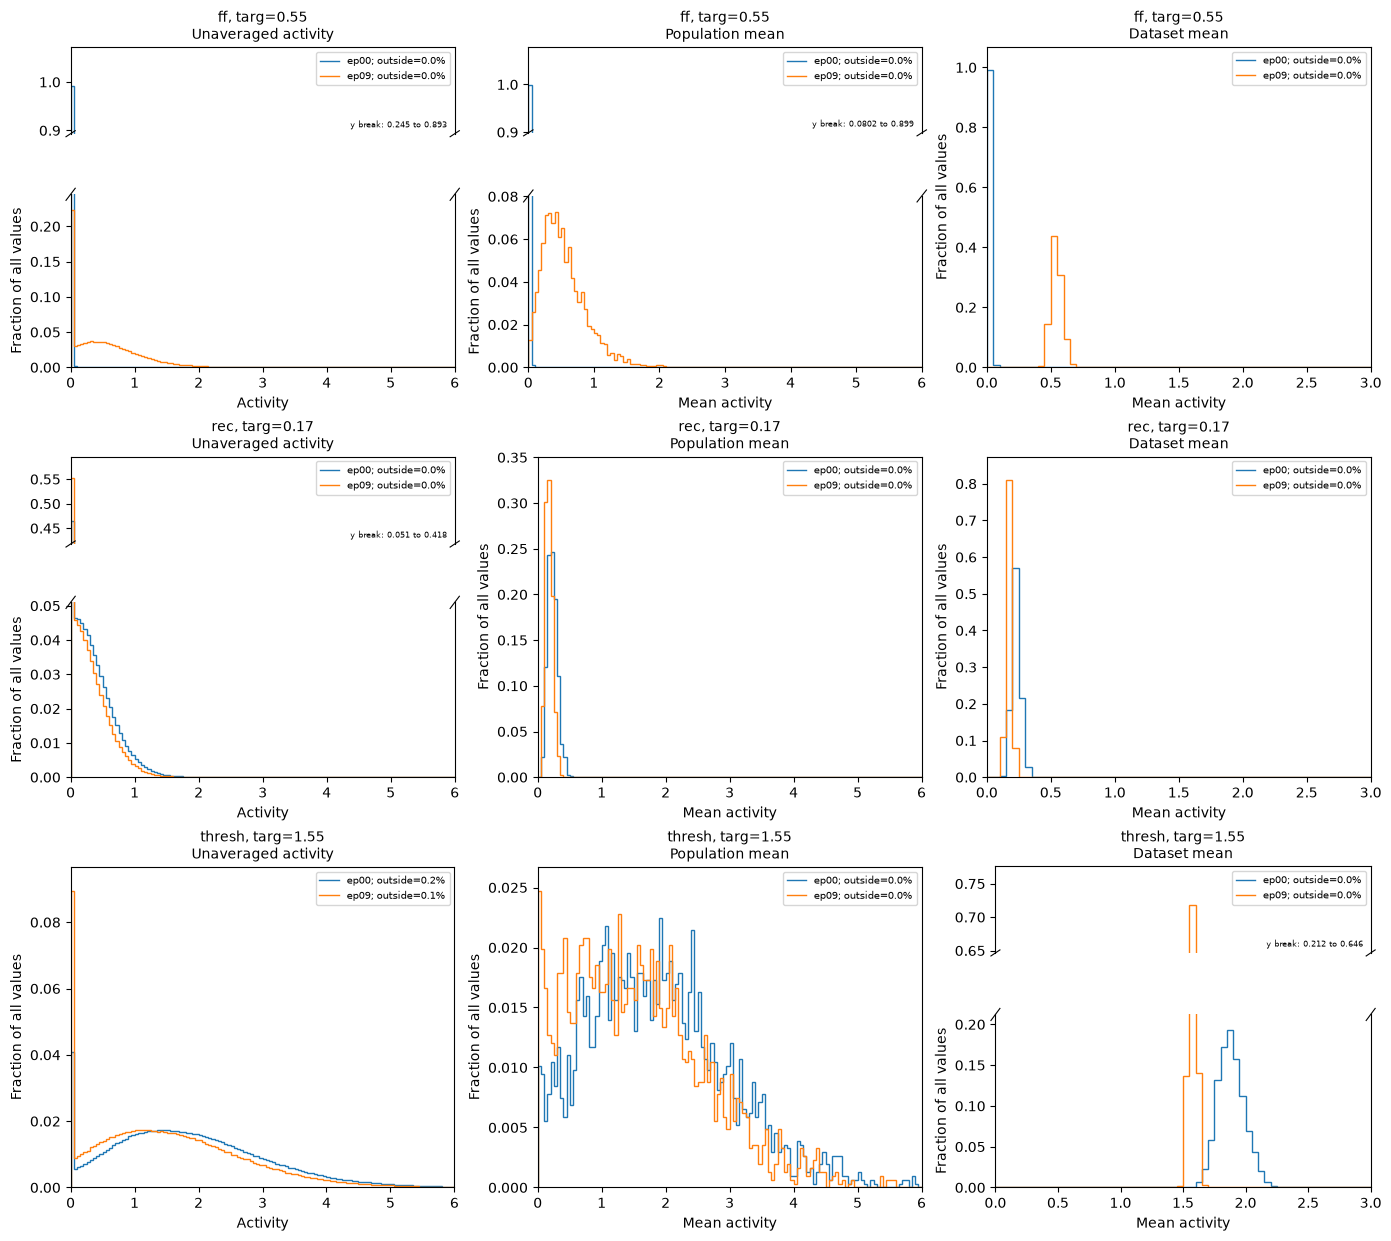

In [10]:
histogram = tables["activity_histograms"]
histogram = histogram[histogram.run.isin(chosen_paths)]
source = 'activity'
models = list(targets)
axes = ("raw", "population", "lifetime") if source == "activity" else ("population", "lifetime")
titles = {"raw": "Unaveraged activity", "population": "Population mean", "lifetime": "Dataset mean"}
data = histogram[(histogram.source == source) & (histogram.bin_scope == "main")]
fig = plt.figure(figsize=FIGSIZE, layout="constrained")
grid = fig.add_gridspec(len(models), len(axes))
for row, model in enumerate(models):
    for col, axis in enumerate(axes):
        g = data[(data.model_code == model) & (data.axis == axis)]
        curves = []
        # Pool counts across seeds; the denominator includes out-of-range values.
        for stage, frame in g.groupby("stage"):
            bins = frame.groupby(["bin_index", "left", "right"])[["count", "n_values"]].sum().reset_index()
            fraction = (bins["count"] / bins.n_values).to_numpy()
            edges = np.r_[bins.left.iloc[0], bins.right]
            label = "trained" if stage == "final" else stage
            label += f"; outside={max(0., 1-fraction.sum()):.1%}"
            curves.append((edges, fraction, label, "--" if stage == "initial" else "-"))
        panels = _histogram_axes(fig, grid[row, col], [values for _, values, _, _ in curves])
        for ax in panels:
            for edges, values, label, style in curves:
                color = CURVE_COLORS.get(label.split(";")[0])
                options = {} if color is None else {"color": color}
                ax.stairs(values, edges, label=label, linestyle=style, **options)
            ax.set_xlim(edges[0], edges[-1])
        panels[0].set_title(f"{model}, targ={targets[model]:g}\n{titles[axis]}", fontsize=10)
        panels[0].legend(fontsize=7, loc="upper right")
        panels[-1].set(xlabel="Activity" if axis == "raw" else "Mean activity",
                       ylabel="Fraction of all values")

figures['G3_activity_histograms'] = fig
for axis in fig.axes:
    if X_LIMITS is not None: axis.set_xlim(X_LIMITS)
    if Y_LIMITS is not None: axis.set_ylim(Y_LIMITS)
if not fig.get_constrained_layout(): fig.tight_layout()
if SHOW_FIGURES: display(fig)
plt.close(fig)

### Initial and final feature means



Edit size, colors, and optional axis limits here; the drawing cell reuses the prepared numbers.

In [11]:
FIGSIZE = (9.2, 4.1*len(models))
COLORS = dict(MODEL_COLORS)
X_LIMITS = None  # e.g. (0, 10); keep None to use the figure's default.
Y_LIMITS = None  # Preserve the automatic frequency-axis limits and any break.

def arm_color(arm):
    return COLORS.get(arm.split("_")[0], "#777777" if arm == "raw" else "#2ca02c")

CURVE_COLORS = {}  # Optional stage colors, e.g. {"initial": "gray", "trained": "blue"}.

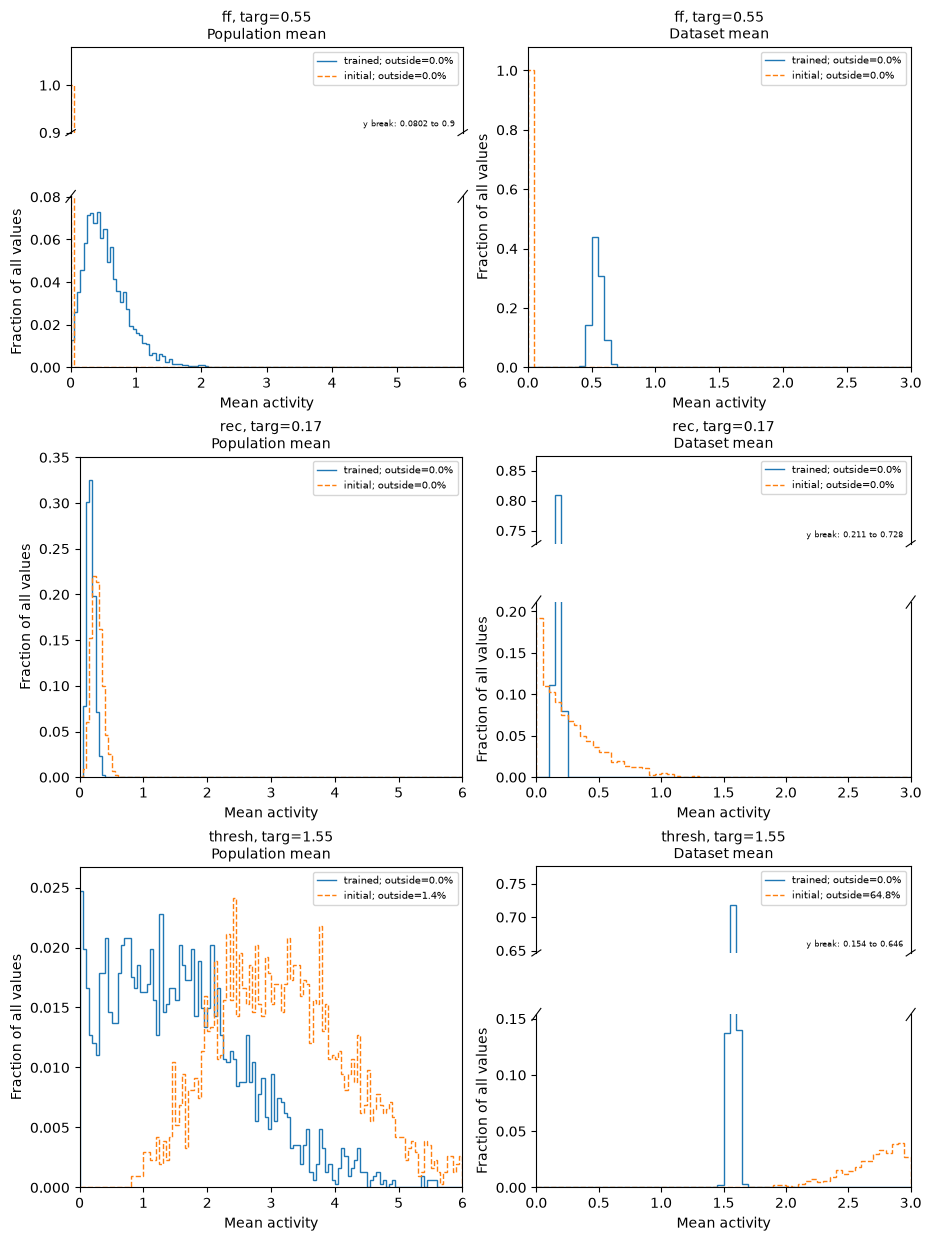

In [12]:
histogram = tables["activity_histograms"]
histogram = histogram[histogram.run.isin(chosen_paths)]
source = 'features'
models = list(targets)
axes = ("raw", "population", "lifetime") if source == "activity" else ("population", "lifetime")
titles = {"raw": "Unaveraged activity", "population": "Population mean", "lifetime": "Dataset mean"}
data = histogram[(histogram.source == source) & (histogram.bin_scope == "main")]
fig = plt.figure(figsize=FIGSIZE, layout="constrained")
grid = fig.add_gridspec(len(models), len(axes))
for row, model in enumerate(models):
    for col, axis in enumerate(axes):
        g = data[(data.model_code == model) & (data.axis == axis)]
        curves = []
        # Pool counts across seeds; the denominator includes out-of-range values.
        for stage, frame in g.groupby("stage"):
            bins = frame.groupby(["bin_index", "left", "right"])[["count", "n_values"]].sum().reset_index()
            fraction = (bins["count"] / bins.n_values).to_numpy()
            edges = np.r_[bins.left.iloc[0], bins.right]
            label = "trained" if stage == "final" else stage
            label += f"; outside={max(0., 1-fraction.sum()):.1%}"
            curves.append((edges, fraction, label, "--" if stage == "initial" else "-"))
        panels = _histogram_axes(fig, grid[row, col], [values for _, values, _, _ in curves])
        for ax in panels:
            for edges, values, label, style in curves:
                color = CURVE_COLORS.get(label.split(";")[0])
                options = {} if color is None else {"color": color}
                ax.stairs(values, edges, label=label, linestyle=style, **options)
            ax.set_xlim(edges[0], edges[-1])
        panels[0].set_title(f"{model}, targ={targets[model]:g}\n{titles[axis]}", fontsize=10)
        panels[0].legend(fontsize=7, loc="upper right")
        panels[-1].set(xlabel="Activity" if axis == "raw" else "Mean activity",
                       ylabel="Fraction of all values")

figures['G3_endpoint_features'] = fig
for axis in fig.axes:
    if X_LIMITS is not None: axis.set_xlim(X_LIMITS)
    if Y_LIMITS is not None: axis.set_ylim(Y_LIMITS)
if not fig.get_constrained_layout(): fig.tight_layout()
if SHOW_FIGURES: display(fig)
plt.close(fig)

### Save this chapter (optional)

Set this switch to True and choose a new export name. Save the notebook before
running this cell. Other chapters and notebooks do not need to be exported first.

In [13]:
SAVE_SECTION = False
SECTION_EXPORT_NAME = 'histograms_v1'
if SAVE_SECTION:
    export_section(SECTION_EXPORT_NAME, ['G3_activity_histograms', 'G3_endpoint_features'], ['activity_metrics', 'activity_histograms', 'activity_statistics'])

## 5. Endpoint changes

Match ep00 and the final recorded probe within each run, axis, and bin scope before subtracting.

In [14]:
ep = tables["activity_metrics"]
# ep00 is the probe after the first adaptation epoch, not the untrained state.
first = ep[ep.stage == "ep00"]
probes = ep[ep.stage.str.startswith("ep")].copy()
probes["probe_epoch"] = probes.stage.str[2:].astype(int)
final = probes[probes.probe_epoch == probes.groupby(["run", "axis", "bin_scope"]).probe_epoch.transform("max")]
if not first.empty and not final.empty:
    pairs = final.merge(first, on=["run", "axis", "bin_scope"], suffixes=("_final", "_first"), validate="one_to_one")
    for key in ("H", "Hhat", "S", "S_prime", "zero_bin_frac"):
        pairs[f"delta_{key}"] = pairs[f"{key}_final"] - pairs[f"{key}_first"]
    tables["endpoint_differences"] = pairs
    tables["endpoint_difference_statistics"] = describe_values(pairs,
        ["arm_final", "targ_final", "split_final", "axis", "bin_scope"],
        [f"delta_{key}" for key in ("H", "Hhat", "S", "S_prime", "zero_bin_frac")])

In [15]:
for name in ['endpoint_differences', 'endpoint_difference_statistics']:
    print(f"{name}: {len(tables[name])} rows (preview below; export keeps every row)")
    display(tables[name].head(12).rename(columns={"lifetime": "dataset"}).replace({"axis": {"lifetime": "dataset"}}))

endpoint_differences: 243 rows (preview below; export keeps every row)


,run,arm_final,model_code_final,targ_final,eta_final,seed_index_final,stage_final,split_final,source_final,axis,...,active_fraction_first,strict_zero_fraction_first,zero_mean_fraction_first,allow_dropped_first,undefined_reason_first,delta_H,delta_Hhat,delta_S,delta_S_prime,delta_zero_bin_frac
0,[local path],ff_trained,ff,0.17,0.0003,0,ep09,test,activity,population,...,0.002306,0.997694,0.787109,True,,3.261786,0.472251,-0.472251,0.360766,-0.683594
1,[local path],ff_trained,ff,0.17,0.0003,0,ep09,test,activity,dataset,...,0.002306,0.997694,0.657025,True,,1.059622,0.179387,-0.179387,0.820613,-1.000000
2,[local path],ff_trained,ff,0.17,0.0003,0,ep09,test,activity,raw,...,0.002306,0.997694,0.997694,True,,2.644826,0.382926,-0.382926,0.231926,-0.379409
3,[local path],ff_trained,ff,0.17,0.0003,1,ep09,test,activity,population,...,0.011993,0.988007,0.399414,True,,3.100113,0.448843,-0.448843,0.472895,-0.861328
4,[local path],ff_trained,ff,0.17,0.0003,1,ep09,test,activity,dataset,...,0.011993,0.988007,0.466942,True,,0.868326,0.147002,-0.147002,0.816243,-0.983471
5,[local path],ff_trained,ff,0.17,0.0003,1,ep09,test,activity,raw,...,0.011993,0.988007,0.988007,True,,2.632976,0.381210,-0.381210,0.240483,-0.406405
6,[local path],ff_trained,ff,0.17,0.0003,2,ep09,test,activity,population,...,0.005139,0.994861,0.652344,True,,3.407858,0.493400,-0.493400,0.341362,-0.673828
7,[local path],ff_trained,ff,0.17,0.0003,2,ep09,test,activity,dataset,...,0.005139,0.994861,0.601240,True,,1.142476,0.193414,-0.193414,0.806586,-1.000000
8,[local path],ff_trained,ff,0.17,0.0003,2,ep09,test,activity,raw,...,0.005139,0.994861,0.994861,True,,2.748167,0.397888,-0.397888,0.231928,-0.393046
9,[local path],ff_trained,ff,0.27,0.0001,0,ep09,test,activity,population,...,0.000206,0.999794,0.958008,True,,3.906310,0.565567,-0.565567,0.363583,-0.836914


endpoint_difference_statistics: 405 rows (preview below; export keeps every row)


,arm_final,targ_final,split_final,axis,bin_scope,metric,expected_n,n,missing_or_invalid,mean,sd,median,q1,q3,min,max
0,ff_trained,0.17,test,dataset,main,delta_H,3,3,0,1.023475,0.114803,1.059622,0.963974,1.101049,0.868326,1.142476
1,ff_trained,0.17,test,dataset,main,delta_Hhat,3,3,0,0.173268,0.019435,0.179387,0.163195,0.186401,0.147002,0.193414
2,ff_trained,0.17,test,dataset,main,delta_S,3,3,0,-0.173268,0.019435,-0.179387,-0.186401,-0.163195,-0.193414,-0.147002
3,ff_trained,0.17,test,dataset,main,delta_S_prime,3,3,0,0.814480,0.005860,0.816243,0.811414,0.818428,0.806586,0.820613
4,ff_trained,0.17,test,dataset,main,delta_zero_bin_frac,3,3,0,-0.994490,0.007792,-1.000000,-1.000000,-0.991736,-1.000000,-0.983471
5,ff_trained,0.17,test,population,main,delta_H,3,3,0,3.256585,0.125690,3.261786,3.180949,3.334822,3.100113,3.407858
6,ff_trained,0.17,test,population,main,delta_Hhat,3,3,0,0.471498,0.018198,0.472251,0.460547,0.482825,0.448843,0.493400
7,ff_trained,0.17,test,population,main,delta_S,3,3,0,-0.471498,0.018198,-0.472251,-0.482825,-0.460547,-0.493400,-0.448843
8,ff_trained,0.17,test,population,main,delta_S_prime,3,3,0,0.391674,0.057976,0.360766,0.351064,0.416830,0.341362,0.472895
9,ff_trained,0.17,test,population,main,delta_zero_bin_frac,3,3,0,-0.739583,0.086179,-0.683594,-0.772461,-0.678711,-0.861328,-0.673828


### Save this chapter (optional)

Set this switch to True and choose a new export name. Save the notebook before
running this cell. Other chapters and notebooks do not need to be exported first.

In [16]:
SAVE_SECTION = False
SECTION_EXPORT_NAME = 'endpoint_changes_v1'
if SAVE_SECTION:
    export_section(SECTION_EXPORT_NAME, [], ['endpoint_differences', 'endpoint_difference_statistics'])

## 6. S scores

Compare six arms: `rec_initial`, `rec_trained`, `ff_initial`, `ff_trained`,
`thresh_initial`, and `thresh_trained`. Population, dataset, and overall S tables
exclude raw-pixel and MLP arms. The violin plots use each model's selected target
for its adapted state and retain every seed in both states.

Overall S is the arithmetic mean of population and dataset S. An undefined axis
propagates to the overall score. All-target tables remain separate from
selected-target tables.

In [17]:
parts = [saved["entropy"].assign(**_identity(path, conditions))
         for path, (conditions, arrays, saved) in distribution_runs.items() if "entropy" in saved]
tables["entropy"] = pd.concat(parts, ignore_index=True)

In [18]:
endpoints = ep[(ep.source == "features") & (ep.bin_scope == "main")]
# Combine the two axes within each run before summarizing scores across seeds.
overall = endpoints[endpoints.axis == "population"].merge(
    endpoints[endpoints.axis == "lifetime"][["run", "S", "S_prime"]],
    on="run", suffixes=("_population", "_lifetime"), validate="one_to_one")
overall["S_overall"] = .5 * (overall.S_population + overall.S_lifetime)
overall["S_prime_overall"] = .5 * (overall.S_prime_population + overall.S_prime_lifetime)
tables["overall_entropy"] = overall[KEYS + ["stage", "split", "S_overall", "S_prime_overall"]]
tables["overall_entropy_statistics"] = describe_values(tables["overall_entropy"], ["arm", "targ", "stage", "split"], ["S_overall", "S_prime_overall"])
tables["overall_S_median_pivot"] = tables["overall_entropy"][tables["overall_entropy"].arm.str.endswith("_trained")].pivot_table(
    index="targ", columns="model_code", values="S_overall", aggfunc="median", dropna=False).reset_index()

In [19]:
# Selected scores use saved entropy rows; the all-target scores above were
# recomputed from feature histograms.
scores = tables["entropy"][tables["entropy"].run.isin(chosen_paths)].pivot(index="run", columns="axis", values="S").rename(
    columns={"population": "S_pop", "lifetime": "S_dataset"})
scores["S_overall"] = .5 * (scores.S_pop + scores.S_dataset)
tables["selected_entropy_scores"] = chosen[KEYS].merge(scores, on="run", validate="one_to_one")
tables["selected_entropy_statistics"] = describe_values(tables["selected_entropy_scores"],
    ["arm", "targ"], ["S_pop", "S_dataset", "S_overall"])

In [20]:
for name in ['overall_entropy', 'overall_entropy_statistics', 'overall_S_median_pivot', 'selected_entropy_scores', 'selected_entropy_statistics']:
    print(f"{name}: {len(tables[name])} rows (preview below; export keeps every row)")
    display(tables[name].head(12).rename(columns={"lifetime": "dataset"}).replace({"axis": {"lifetime": "dataset"}}))

overall_entropy: 90 rows (preview below; export keeps every row)


,run,arm,model_code,targ,eta,seed_index,stage,split,S_overall,S_prime_overall
0,[local path],ff_trained,ff,0.17,0.0003,0,final,test,0.674181,0.590689
1,[local path],ff_trained,ff,0.17,0.0003,1,final,test,0.690985,0.653151
2,[local path],ff_trained,ff,0.17,0.0003,2,final,test,0.656593,0.573974
3,[local path],ff_trained,ff,0.27,0.0001,0,final,test,0.612070,0.576645
4,[local path],ff_trained,ff,0.27,0.0001,1,final,test,0.632571,0.626405
5,[local path],ff_trained,ff,0.27,0.0001,2,final,test,0.597568,0.568690
6,[local path],ff_trained,ff,0.20,0.0003,0,final,test,0.644524,0.577278
7,[local path],ff_trained,ff,0.20,0.0003,1,final,test,0.665126,0.642461
8,[local path],ff_trained,ff,0.20,0.0003,2,final,test,0.634453,0.572456
9,[local path],ff_trained,ff,0.35,0.0001,0,final,test,0.578532,0.559825


overall_entropy_statistics: 60 rows (preview below; export keeps every row)


,arm,targ,stage,split,metric,expected_n,n,missing_or_invalid,mean,sd,median,q1,q3,min,max
0,ff_initial,NaN,initial,test,S_overall,3,3,0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,ff_initial,NaN,initial,test,S_prime_overall,3,3,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,ff_trained,0.17,final,test,S_overall,3,3,0,0.673920,0.014042,0.674181,0.665387,0.682583,0.656593,0.690985
3,ff_trained,0.17,final,test,S_prime_overall,3,3,0,0.605938,0.034075,0.590689,0.582331,0.621920,0.573974,0.653151
4,ff_trained,0.20,final,test,S_overall,3,3,0,0.648034,0.012766,0.644524,0.639488,0.654825,0.634453,0.665126
5,ff_trained,0.20,final,test,S_prime_overall,3,3,0,0.597398,0.031925,0.577278,0.574867,0.609869,0.572456,0.642461
6,ff_trained,0.27,final,test,S_overall,3,3,0,0.614070,0.014360,0.612070,0.604819,0.622320,0.597568,0.632571
7,ff_trained,0.27,final,test,S_prime_overall,3,3,0,0.590580,0.025539,0.576645,0.572668,0.601525,0.568690,0.626405
8,ff_trained,0.35,final,test,S_overall,3,3,0,0.580172,0.019152,0.578532,0.568056,0.591468,0.557579,0.604405
9,ff_trained,0.35,final,test,S_prime_overall,3,3,0,0.568626,0.024111,0.559825,0.552161,0.580690,0.544497,0.601556


overall_S_median_pivot: 9 rows (preview below; export keeps every row)


model_code,targ,ff,rec,thresh
0,0.17,0.674181,0.764005,0.798431
1,0.20,0.644524,0.741918,0.797272
2,0.27,0.612070,0.699729,0.711926
3,0.35,0.578532,0.669513,0.695132
4,0.55,0.528487,0.603321,0.608529
5,0.90,0.485672,0.509943,0.515511
6,1.15,0.472675,0.502110,0.485478
7,1.40,0.457824,0.473563,0.463769
8,1.55,0.449656,0.450142,0.458659


selected_entropy_scores: 18 rows (preview below; export keeps every row)


,run,arm,model_code,targ,eta,seed_index,S_dataset,S_pop,S_overall
0,[local path],ff_trained,ff,0.55,0.0001,0,0.733587,0.323388,0.528487
1,[local path],ff_trained,ff,0.55,0.0001,1,0.736730,0.391713,0.564222
2,[local path],ff_trained,ff,0.55,0.0001,2,0.676154,0.312838,0.494496
3,[local path],rec_trained,rec,0.17,0.0010,0,0.856071,0.677143,0.766607
4,[local path],rec_trained,rec,0.17,0.0010,1,0.843175,0.679348,0.761262
5,[local path],rec_trained,rec,0.17,0.0010,2,0.848945,0.679066,0.764005
6,[local path],thresh_trained,thresh,1.55,0.1000,0,0.797375,0.104499,0.450937
7,[local path],thresh_trained,thresh,1.55,0.1000,1,0.818724,0.101457,0.460090
8,[local path],thresh_trained,thresh,1.55,0.1000,2,0.814296,0.103021,0.458659
9,[local path],ff_initial,ff,NaN,NaN,0,1.000000,1.000000,1.000000


selected_entropy_statistics: 18 rows (preview below; export keeps every row)


,arm,targ,metric,expected_n,n,missing_or_invalid,mean,sd,median,q1,q3,min,max
0,ff_initial,NaN,S_pop,3,3,0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,ff_initial,NaN,S_dataset,3,3,0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,ff_initial,NaN,S_overall,3,3,0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,ff_trained,0.55,S_pop,3,3,0,0.342646,0.034962,0.323388,0.318113,0.357550,0.312838,0.391713
4,ff_trained,0.55,S_dataset,3,3,0,0.715490,0.027845,0.733587,0.704870,0.735159,0.676154,0.736730
5,ff_trained,0.55,S_overall,3,3,0,0.529068,0.028468,0.528487,0.511492,0.546354,0.494496,0.564222
6,rec_initial,NaN,S_pop,3,3,0,0.588131,0.001607,0.587666,0.587052,0.588978,0.586438,0.590290
7,rec_initial,NaN,S_dataset,3,3,0,0.352926,0.000724,0.352528,0.352418,0.353235,0.352308,0.353943
8,rec_initial,NaN,S_overall,3,3,0,0.470529,0.001161,0.470097,0.469735,0.471107,0.469373,0.472116
9,rec_trained,0.17,S_pop,3,3,0,0.678519,0.000980,0.679066,0.678104,0.679207,0.677143,0.679348


### Initial and adapted S scores: six arms

Finite seed scores and their medians remain visible, including constant or
single-value groups. Undefined scores are omitted from the plot and counted
in the statistics table.

Edit size, colors, and optional axis limits here; the drawing cell reuses the prepared numbers.

In [21]:
FIGSIZE = (18, 5)
COLORS = dict(MODEL_COLORS)
# Set limits to (min, max); None keeps the figure defaults.
X_LIMITS = None
Y_LIMITS = None

def arm_color(arm):
    return COLORS.get(arm.split("_")[0], "#777777" if arm == "raw" else "#2ca02c")

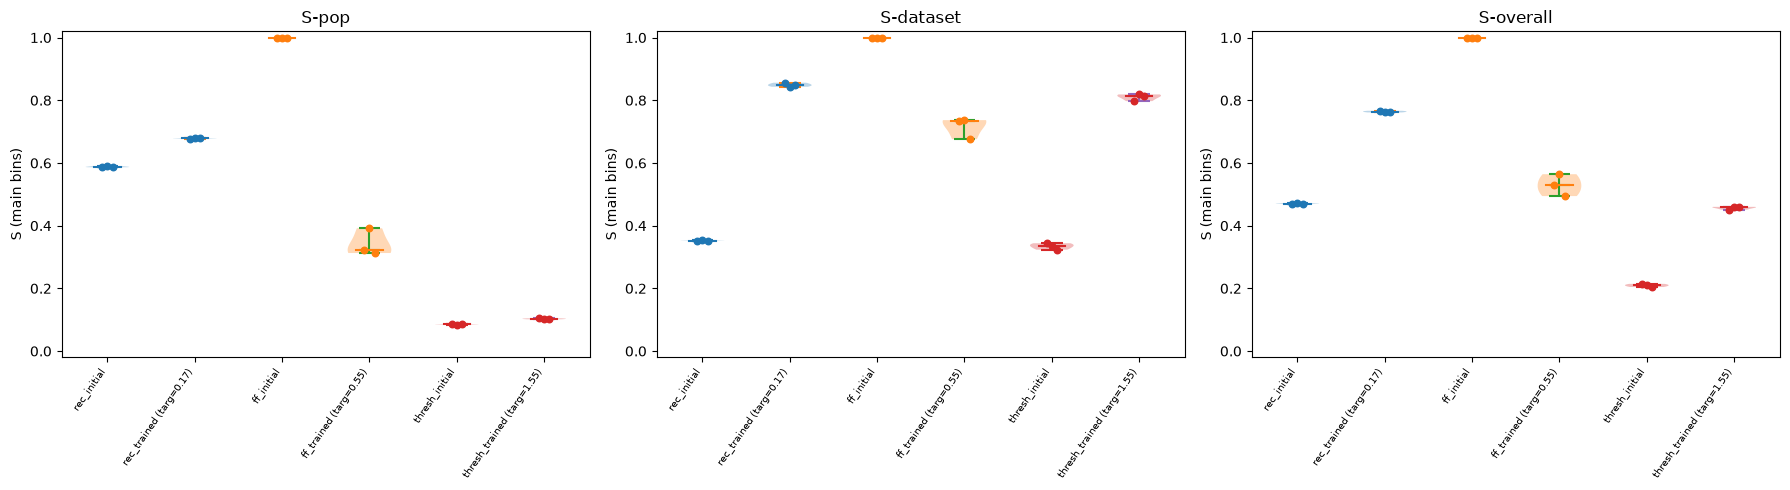

In [22]:
fig, axs = plt.subplots(1, 3, figsize=FIGSIZE)
for ax, metric, title in zip(axs, ("S_pop", "S_dataset", "S_overall"), ("S-pop", "S-dataset", "S-overall")):
    for i, arm in enumerate(arms):
        scores = tables["selected_entropy_scores"]
        _violin_points(ax, scores.loc[scores.arm == arm, metric], i, arm_color(arm))
    ax.set_xticks(range(len(arms)), arm_labels, rotation=55, ha="right", fontsize=7)
    ax.set(title=title, ylabel="S (main bins)", ylim=(-.02, 1.02))
figures["G3_S_violin"] = fig

figures['G3_S_violin'] = fig
for axis in fig.axes:
    if X_LIMITS is not None: axis.set_xlim(X_LIMITS)
    if Y_LIMITS is not None: axis.set_ylim(Y_LIMITS)
if not fig.get_constrained_layout(): fig.tight_layout()
if SHOW_FIGURES: display(fig)
plt.close(fig)

### Save this chapter (optional)

Set this switch to True and choose a new export name. Save the notebook before
running this cell. Other chapters and notebooks do not need to be exported first.

In [23]:
SAVE_SECTION = False
SECTION_EXPORT_NAME = 'scores_v1'
if SAVE_SECTION:
    export_section(SECTION_EXPORT_NAME, ['G3_S_violin'], ['entropy', 'overall_entropy', 'overall_entropy_statistics', 'overall_S_median_pivot', 'selected_entropy_scores', 'selected_entropy_statistics'])

## 7. Activity and bin diagnostics

Strict zero fractions and zero-bin fractions are different quantities. The common range is a separate diagnostic and does not replace the main S definition.

### Activity diagnostics across targets



Edit size, colors, and optional axis limits here; the drawing cell reuses the prepared numbers.

In [24]:
FIGSIZE = (17, 4)
COLORS = dict(MODEL_COLORS)
# Set limits to (min, max); None keeps the figure defaults.
X_LIMITS = None
Y_LIMITS = None

def arm_color(arm):
    return COLORS.get(arm.split("_")[0], "#777777" if arm == "raw" else "#2ca02c")

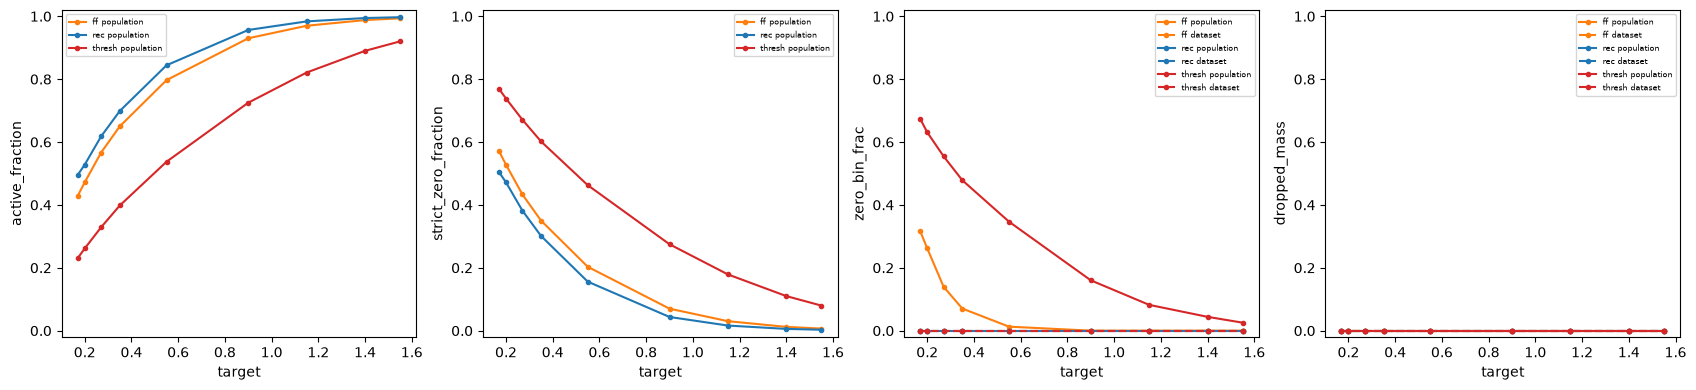

In [25]:
fig, axs = plt.subplots(1, 4, figsize=FIGSIZE)
metrics = tables["activity_metrics"]
metrics = metrics[(metrics.source == "features") & (metrics.bin_scope == "main") & metrics.arm.str.endswith("_trained")]
for ax, key in zip(axs, ("active_fraction", "strict_zero_fraction", "zero_bin_frac", "dropped_mass")):
    for model in models:
        # Active/strict-zero fractions are shared across axes; plot one copy per model.
        axes = ("population",) if key in ("active_fraction", "strict_zero_fraction") else ("population", "lifetime")
        for axis in axes:
            g = metrics[(metrics.model_code == model) & (metrics.axis == axis)].groupby("targ")[key].median()
            ax.plot(g.index, g, marker=".", color=COLORS[model],
                    linestyle="-" if axis == "population" else "--",
                    label=f"{model} {'dataset' if axis == 'lifetime' else axis}")
    ax.set(xlabel="target", ylabel=key, ylim=(-.02, 1.02))
    ax.legend(fontsize=6)
figures["G3_activity_diagnostics"] = fig

figures['G3_activity_diagnostics'] = fig
for axis in fig.axes:
    if X_LIMITS is not None: axis.set_xlim(X_LIMITS)
    if Y_LIMITS is not None: axis.set_ylim(Y_LIMITS)
if not fig.get_constrained_layout(): fig.tight_layout()
if SHOW_FIGURES: display(fig)
plt.close(fig)

### Main bins and common-range bins



Edit size, colors, and optional axis limits here; the drawing cell reuses the prepared numbers.

In [26]:
FIGSIZE = (12, 5)
COLORS = dict(MODEL_COLORS)
# Set limits to (min, max); None keeps the figure defaults.
X_LIMITS = None
Y_LIMITS = None

def arm_color(arm):
    return COLORS.get(arm.split("_")[0], "#777777" if arm == "raw" else "#2ca02c")

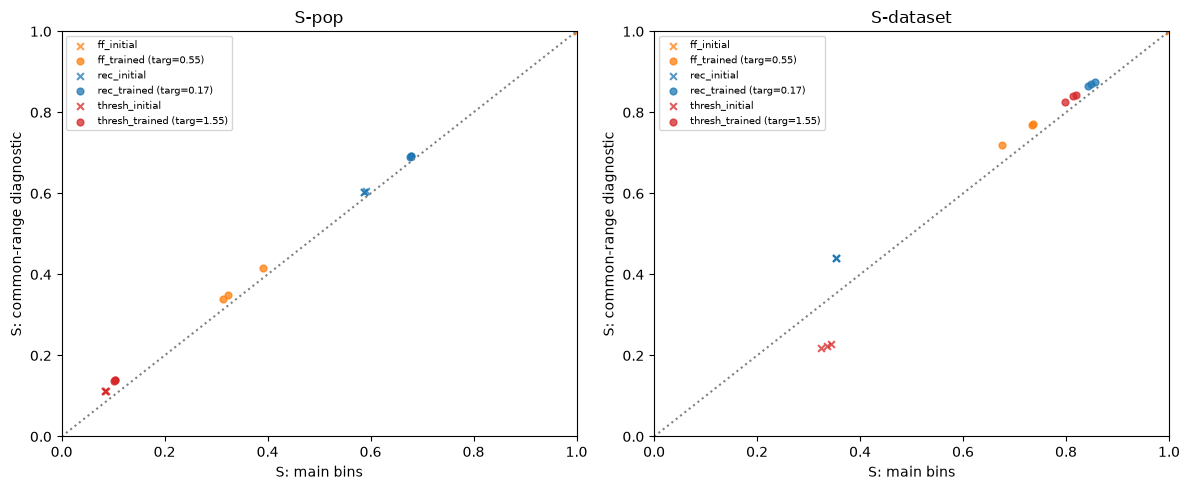

In [27]:
metrics = tables["activity_metrics"][tables["activity_metrics"].run.isin(chosen_paths)]
data = metrics[metrics.source == "features"]
# Hold the run and axis fixed so each point compares only the bin-range choice.
both = data[data.bin_scope == "main"].merge(
    data[data.bin_scope == "common_range_diagnostic"], on=["run", "axis"],
    suffixes=("_main", "_common"), validate="one_to_one")
fig, axs = plt.subplots(1, 2, figsize=FIGSIZE)
for ax, axis, title in zip(axs, ("population", "lifetime"), ("S-pop", "S-dataset")):
    for arm, g in both[both.axis == axis].groupby("arm_main"):
        ax.scatter(g.S_main, g.S_common, color=arm_color(arm), alpha=.75,
                   marker="x" if arm.endswith("initial") else "o", label=_arm_label(arm, targets), s=24)
    ax.plot([0, 1], [0, 1], color="gray", linestyle=":")
    ax.set(title=title, xlabel="S: main bins", ylabel="S: common-range diagnostic", xlim=(0, 1), ylim=(0, 1))
    ax.legend(fontsize=7)

figures['G3_bin_range_diagnostic'] = fig
for axis in fig.axes:
    if X_LIMITS is not None: axis.set_xlim(X_LIMITS)
    if Y_LIMITS is not None: axis.set_ylim(Y_LIMITS)
if not fig.get_constrained_layout(): fig.tight_layout()
if SHOW_FIGURES: display(fig)
plt.close(fig)

### Save this chapter (optional)

Set this switch to True and choose a new export name. Save the notebook before
running this cell. Other chapters and notebooks do not need to be exported first.

In [28]:
SAVE_SECTION = False
SECTION_EXPORT_NAME = 'diagnostics_v1'
if SAVE_SECTION:
    export_section(SECTION_EXPORT_NAME, ['G3_activity_diagnostics', 'G3_bin_range_diagnostic'], ['activity_metrics', 'activity_statistics'])

## Export all figures and tables in this notebook

Run all main chapters first. Set `SAVE_NUMBERS=True` in Settings and choose
a new `EXPORT_NAME`. This saves the CSVs listed in `OWNED_TABLES`, prepared
main-chapter figures in the enabled formats, input/HP/population hashes,
effective targets, a notebook copy, and export settings.

Chapter exports must use different names. Save the notebook file before
exporting; after style changes, rerun the drawing cells and use a new name.

Optional saved-parameter inference and fixed-point checks are implemented in
[02_adaptation.ipynb](02_adaptation.ipynb). Optional UMAP fits are implemented
in [05_geometry.ipynb](05_geometry.ipynb). Each has its own computation switch
and can redraw from saved additional numbers.

In [29]:
print("Tables owned by this notebook:", OWNED_TABLES)
print("Figures prepared:", list(figures))
if SAVE_NUMBERS:
    export_section(EXPORT_NAME, list(figures), OWNED_TABLES)
else:
    print("Preview only. Enable SAVE_NUMBERS and choose a new EXPORT_NAME to export.")

Tables owned by this notebook: ['activity_metrics', 'activity_histograms', 'activity_statistics', 'endpoint_differences', 'endpoint_difference_statistics', 'entropy', 'overall_entropy', 'overall_entropy_statistics', 'overall_S_median_pivot', 'selected_entropy_scores', 'selected_entropy_statistics']
Figures prepared: ['G3_activity_histograms', 'G3_endpoint_features', 'G3_S_violin', 'G3_activity_diagnostics', 'G3_bin_range_diagnostic']
Preview only. Enable SAVE_NUMBERS and choose a new EXPORT_NAME to export.
